# Analyzing Location/Scale behavior with class imbalance across sites

### In this notebook, we will explore what is the effect of applying ComBat on scenarios where the target and the site are dependent, e.g., the classes across sites are imbalanced.

This is a common scenario in real-world scenarios, when the majority of one class (patients) is acquired in a subset of sites, while the majority of another class (controls) is acquired in a different subset of sites.

Another common scenario is the non-overlapping age range in datasets. 

We will simulate two situations:

- First, we will harmonize the data without using the target to preserve the it's variance.
- Second, we will harmonize the data passing the target as a covariate to the harmonization model.

From these scenarios, only the first is compatible with a Machine Learning pipeline, as the target is unknown for the test samples.

In [ ]:
# Imports
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from uniharmony import verbosity
from uniharmony.combat import NeuroComBat
from uniharmony.datasets import make_multisite_classification
from uniharmony.plot import plot_decision_boundary_2d
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
verbosity("error")
random_state = 23

### Let's create an example where no EoS will be simulated, and only real signal will be presented.

To generate the site-target dependence, we will generate an imbalance problem by site, making 10% of the data in Site 0 to belong to Class 1.

In [ ]:
# Data generation
X, y, sites = make_multisite_classification(
    n_features=2,
    signal_strength=1,
    site_effect_strength=0,
    balance_per_site=[0.1, 0.9],
    site_effect_homogeneous=True,
    site_effect_type="location",
    signal_type="blobs",
    random_state=random_state,
)

X_train, X_test, y_train, y_test, sites_train, sites_test = train_test_split(
    X, y, sites
)

clf = LogisticRegression()
combat = NeuroComBat()

### Now let's apply our the harmonization in these two Scenarios.

2026-05-26 00:11:20 [debug    ] Making design matrix           src=DesignMatrixMixin
2026-05-26 00:11:20 [debug    ] Fitted site encoder: 2 sites   src=DesignMatrixMixin
2026-05-26 00:11:20 [debug    ] Making design matrix           src=DesignMatrixMixin
2026-05-26 00:11:20 [debug    ] Sites encoded: 750 samples x 2 sites src=DesignMatrixMixin
2026-05-26 00:11:20 [debug    ] Design matrix shape: (750, 2)  src=DesignMatrixMixin
2026-05-26 00:11:20 [debug    ] Standardizing data across features src=StandardizationMixin
2026-05-26 00:11:20 [debug    ] Standardizing new data using fitted data src=StandardizationMixin
2026-05-26 00:11:20 [debug    ] Standardization stats:         src=StandardizationMixin
2026-05-26 00:11:20 [debug    ]   Grand mean range: [0.1577, 0.6375] src=StandardizationMixin
2026-05-26 00:11:20 [debug    ]   Pooled std range: [1.0078, 1.0322] src=StandardizationMixin
2026-05-26 00:11:20 [debug    ]   Standardized data mean: -0.000000 (should be ~0) src=StandardizationM

2026-05-26 00:11:20 [debug    ] _iteration_solver converged in 3 iterations (change=0.000000) src=LocationAndScaleMixin
2026-05-26 00:11:20 [debug    ] _iteration_solver converged in 3 iterations (change=0.000000) src=LocationAndScaleMixin
2026-05-26 00:11:20 [debug    ] Making design matrix           src=DesignMatrixMixin
2026-05-26 00:11:20 [debug    ] Sites encoded: 750 samples x 2 sites src=DesignMatrixMixin
2026-05-26 00:11:20 [debug    ] Design matrix shape: (750, 2)  src=DesignMatrixMixin
2026-05-26 00:11:20 [debug    ] Standardizing new data using fitted data src=StandardizationMixin
2026-05-26 00:11:20 [debug    ] Standardization stats:         src=StandardizationMixin
2026-05-26 00:11:20 [debug    ]   Grand mean range: [0.1577, 0.6375] src=StandardizationMixin
2026-05-26 00:11:20 [debug    ]   Pooled std range: [1.0078, 1.0322] src=StandardizationMixin
2026-05-26 00:11:20 [debug    ]   Standardized data mean: -0.000000 (should be ~0) src=StandardizationMixin
2026-05-26 00:11:

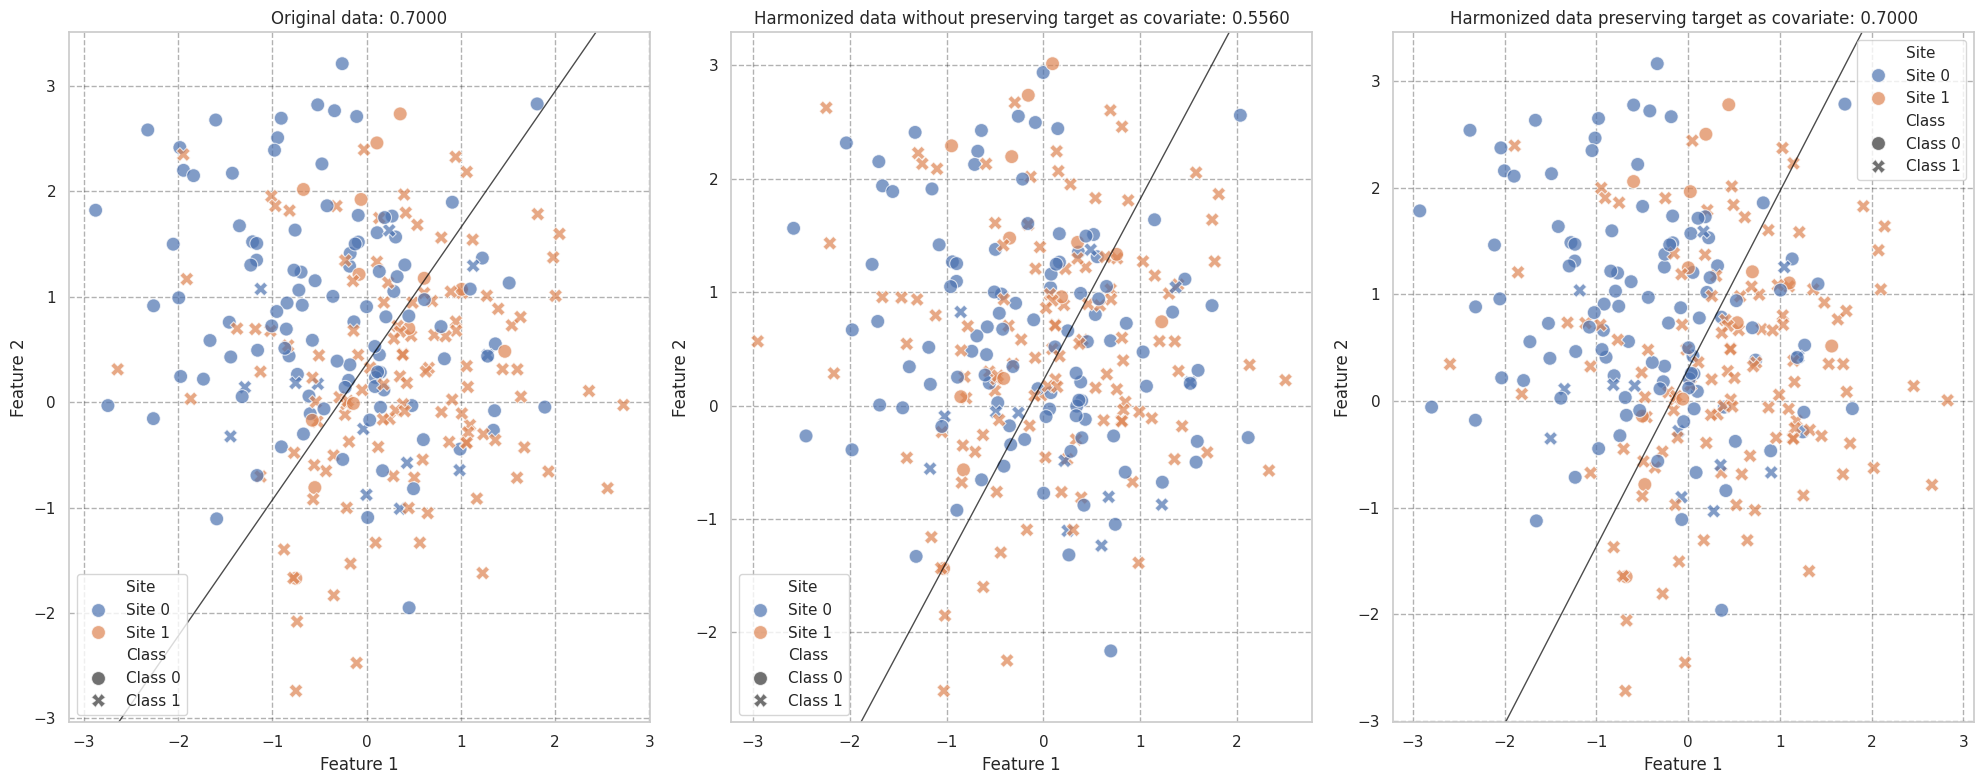

In [140]:
# Harmonization

# Harmonizing without preserving the target as covariate
X_harmonized_train = combat.fit_transform(X=X_train, sites=sites_train)
X_harmonized = combat.transform(X_test, sites_test)


# Preserve the target as covariate
# This is the key line: we need to include the target variable as a covariate
# to preserve its relationship with the features during harmonization.
X_harmonized_train_target = combat.fit_transform(
    X=X_train, sites=sites_train, categorical_covariates=y_train.reshape(-1, 1)
)

#############################################################################################
# This step represent *data leakage* in a ML learning pipeline, as the test target is unknown. 
X_harmonized_target = combat.transform(
    X_test, sites_test, categorical_covariates=y_test.reshape(-1, 1)
)
#############################################################################################


####### Prepare data for plotting.
# Create DataFrame for easier plotting
df = pd.DataFrame(
    {
        "Feature 1": X_test[:, 0],
        "Feature 2": X_test[:, 1],
        "Class": [f"Class {c}" for c in y_test],
        "Site": [f"Site {s}" for s in sites_test],
    }
)

# Create DataFrame for easier plotting
df_harm = pd.DataFrame(
    {
        "Feature 1": X_harmonized[:, 0],
        "Feature 2": X_harmonized[:, 1],
        "Class": [f"Class {c}" for c in y_test],
        "Site": [f"Site {s}" for s in sites_test],
    }
)


# Create DataFrame for easier plotting
df_harm_target = pd.DataFrame(
    {
        "Feature 1": X_harmonized_target[:, 0],
        "Feature 2": X_harmonized_target[:, 1],
        "Class": [f"Class {c}" for c in y_test],
        "Site": [f"Site {s}" for s in sites_test],
    }
)

fig, ax = plt.subplots(1, 3, figsize=(20, 8))
# Plot with site as hue and class as style
sns.scatterplot(
    data=df,
    x="Feature 1",
    y="Feature 2",
    hue="Site",
    style="Class",
    s=100,
    alpha=0.7,
    ax=ax[0],
    hue_order=["Site 0", "Site 1"],
    style_order=["Class 0", "Class 1"],
)
clf.fit(X_train, y_train)
scores = clf.score(X_test, y_test)
ax[0].set_title(f"Original data: {scores:.4f}")
ax[0].grid(alpha=0.3, color="black", linestyle="--")
plot_decision_boundary_2d(ax[0], clf)

# Plot with site as hue and class as style
sns.scatterplot(
    data=df_harm,
    x="Feature 1",
    y="Feature 2",
    hue="Site",
    style="Class",
    s=100,
    alpha=0.7,
    ax=ax[1],
    hue_order=["Site 0", "Site 1"],
    style_order=["Class 0", "Class 1"],
)
clf.fit(X_harmonized_train, y_train)
scores = clf.score(X_harmonized, y_test)

ax[1].set_title(f"Harmonized data without preserving target as covariate: {scores:.4f}")
ax[1].grid(alpha=0.3, color="black", linestyle="--")

plot_decision_boundary_2d(ax[1], clf)
# Plot with site as hue and class as style
sns.scatterplot(
    data=df_harm_target,
    x="Feature 1",
    y="Feature 2",
    hue="Site",
    style="Class",
    s=100,
    alpha=0.7,
    ax=ax[2],
    hue_order=["Site 0", "Site 1"],
    style_order=["Class 0", "Class 1"],
)
clf.fit(X_harmonized_train_target, y_train)
scores = clf.score(X_harmonized_target, y_test)

ax[2].set_title(f"Harmonized data preserving target as covariate: {scores:.4f}")
ax[2].grid(alpha=0.3, color="black", linestyle="--")
plot_decision_boundary_2d(ax[2], clf)

plt.tight_layout()


### Take-home message

Location/Scale methods, in this case, NeuroComBat struggles to preserve the target variance in class imbalance scenarios unless we preserve it as a covariate.

An important clarification is that preserving the target as a covariate may be suited for statistical analysis, but violates the assumptions of ML scenarios.

### Solution

You can check the solutions of this notebook [here](https://github.com/N-Nieto/OHBM2026_Educational_course_harmonization/tree/main/solutions/block03)